In [2]:
from extractor import PDBBindProcessor
from matplotlib import pyplot as plt
import pandas as pd
from tokenizer import PDBBindDataset
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from model import HQDeepDTAF
from evaluator import EValuator
from tqdm import tqdm
import math

In [2]:
processor = PDBBindProcessor()
processor.extract_subset("refined")

df_refined = processor.build_dataset(subset="refined")
df_refined.to_csv("pdbbind_refined.csv", index=False)

df_core = processor.build_dataset(subset="core")
df_core.to_csv("pdbbind_core.csv", index=False)

Распаковка 4057 комплексов...


0it [00:00, ?it/s]

66444it [01:20, 820.32it/s] 


Распаковка завершена.
Запуск параллельного парсинга на 8 ядрах...


100%|██████████| 4057/4057 [00:42<00:00, 96.10it/s] 


Успешно: 3995, Ошибок: 62
Counter({'too_long': 61, "Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8": 1})
Запуск параллельного парсинга на 8 ядрах...


100%|██████████| 290/290 [00:03<00:00, 95.26it/s] 

Успешно: 288, Ошибок: 2
Counter({'too_long': 1, "Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8": 1})


In [3]:
# Убираем пересечения: Train = Refined - Core
df_refined = pd.read_csv("pdbbind_refined.csv")
df_core = pd.read_csv("pdbbind_core.csv")
train_df = df_refined[~df_refined['pdb_id'].isin(df_core['pdb_id'])]
train_df.to_csv("pdbbind_train.csv", index=False)

test_df = df_core
test_df.to_csv("pdbbind_test.csv", index=False)

3707
288


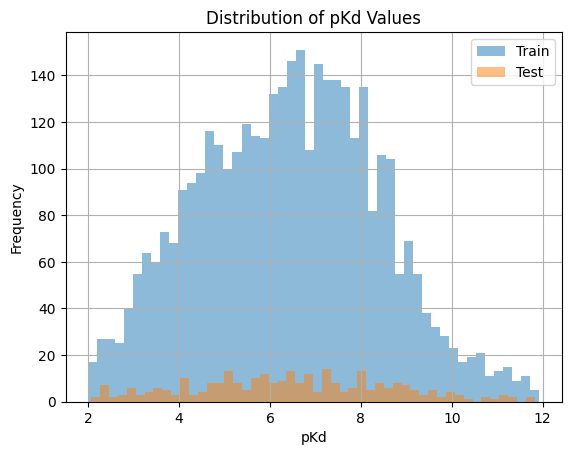

In [5]:
print(len(train_df))
print(len(test_df))

train_df['pkd'].hist(bins=50, alpha=0.5, label='Train')
test_df['pkd'].hist(bins=50, alpha=0.5, label='Test')
plt.xlabel('pKd')
plt.ylabel('Frequency')
plt.title('Distribution of pKd Values')
plt.legend()
plt.show()

In [7]:
train_df['seq'].str.len().describe()

count    3707.000000
mean      428.585379
std       334.207839
min        56.000000
25%       223.000000
50%       297.000000
75%       501.500000
max      1976.000000
Name: seq, dtype: float64

In [3]:
def get_loss_bar(loss_val, bar_len=10):
    # Используем log10 для нормализации динамического диапазона
    # Добавляем 1e-9, чтобы избежать log(0)
    log_loss = math.log10(loss_val + 1e-9)
    
    # Масштабируем: допустим, мы ожидаем лосс от 50 (log ~1.7) до 0.1 (log -1)
    # Сделаем простую линейную закраску для диапазона log_loss от -1 до 2
    level = (log_loss + 1) / 3  # нормализуем в [0, 1]
    level = max(0, min(1, level)) # ограничиваем
    
    filled = int(level * bar_len)
    return "[" + "█" * filled + " " * (bar_len - filled) + "]"

In [ ]:
# 1. Инициализируем датасеты, чтобы узнать реальные размеры словарей, длины согласно статье.
train_ds = PDBBindDataset("pdbbind_train.csv", max_prot=1000, max_lig=150, max_pock=63)
test_ds = PDBBindDataset("pdbbind_core.csv", max_prot=1000, max_lig=150, max_pock=63)

# 2. Динамическая конфигурация
config = {
    # Берем размер словаря + 1 для запаса на Padding (0)
    'prot_vocab': max(train_ds.prot_vocab.values()) + 1,
    'lig_vocab': max(train_ds.lig_vocab.values()) + 1,
    'embed_dim': 128,
    'n_qubits': 9,
    'q_layers': 8,
    'cnn_mode': 'parallel',
    'max_prot': 1000,
    'max_lig': 128, # надо попробовать 64
    'max_pock': 63
}

# 3. Инициализация модели и железа
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HQDeepDTAF(config).to(device)
evaluator = EValuator(model, device)

# 4. Настройка обучения
# optimizer = optim.Adam(model.parameters(), lr=0.001)
classic_params = (
    list(model.protein_net.parameters()) + 
    list(model.ligand_net.parameters()) + 
    list(model.pocket_net.parameters()) +
    list(model.pre_quantum.parameters()) +
    list(model.regressor.parameters())
)
quantum_params = model.quantum_core.parameters()

# CNN и обвязка любят Adam за скорость
classic_optimizer = optim.AdamW(classic_params, lr=0.001)

# Квантовое ядро часто лучше учится на SGD или Adagrad, 
# так как они меньше "шумят" в фазовом пространстве
quantum_optimizer = optim.AdamW(quantum_params, lr=0.0001)
# quantum_optimizer = optim.SGD(quantum_params, lr=0.0001, momentum=0.9)

criterion = torch.nn.MSELoss()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

def train(epochs=20): # По статье авторы используют 20 эпох 
    print(f"Starting training on {device}...")
    history = {
        'train_loss': [],
        'val_rmse': [],
        'val_pearson': [],
        'val_ci': []
    }
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        # Создаем обертку над лоадером
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch", leave=True)
        
        for i, (prot, lig, pock, y) in enumerate(pbar):
            prot, lig, pock, y = prot.to(device), lig.to(device), pock.to(device), y.to(device)
            
            classic_optimizer.zero_grad()
            quantum_optimizer.zero_grad()
            output = model(prot, lig, pock).view(-1)
            loss = criterion(output, y)
            loss.backward()
            classic_optimizer.step()
            quantum_optimizer.step()
            
            current_loss = loss.item()
            total_loss += current_loss
            
            # Генерируем визуальную полоску лосса
            l_bar = get_loss_bar(current_loss)
            
            # Выводим в tqdm: текущий лосс, средний и нашу полоску
            avg_loss = total_loss / (i + 1)
            pbar.set_postfix_str(f"Loss: {current_loss:.4f} {l_bar} Avg: {avg_loss:.4f}")

        # Валидация метрик (RMSE, Pearson R, CI) в конце эпохи
        rmse, r_val, ci_val = evaluator.evaluate(test_loader)
        history['train_loss'].append(avg_loss)
        history['val_rmse'].append(rmse)
        history['val_pearson'].append(r_val)
        history['val_ci'].append(ci_val)
        
        # Печатаем итоги эпохи (в статье используются именно эти метрики [cite: 515, 516, 521])
        print(f"   ∟ Valid: RMSE {rmse:.4f} | R {r_val:.4f} | CI {ci_val:.4f}")
        print("-" * 60)
    return history

In [6]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 10))

    # 1. Loss (Обучение)
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.title('Learning Curve (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    # 2. RMSE
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['val_rmse'], 'r-', label='Val RMSE')
    plt.title('Validation RMSE')
    plt.xlabel('Epochs')
    plt.grid(True)

    # 3. Pearson R
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['val_pearson'], 'g-', label='Pearson R')
    plt.title('Correlation (Pearson R)')
    plt.xlabel('Epochs')
    plt.ylabel('R')
    plt.grid(True)

    # 4. CI
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['val_ci'], 'm-', label='Concordance Index')
    plt.title('Ranking Accuracy (CI)')
    plt.xlabel('Epochs')
    plt.ylabel('CI')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('learning_report.png')
    plt.show()

In [ ]:
history = train(20)
plot_history(history)